# Command Center Logic

This notebook builds the AI logic for the airport Command Center. It combines live flight status, ground resources, infrastructure capacity, weather disruption signals, conflict detection, priority scoring, and recommended operational actions.

## 1. Setup

In [1]:
import random
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Generate Live Airport State

In [2]:
AIRLINES = ['Air India', 'IndiGo', 'SpiceJet', 'Vistara', 'Akasa', 'AirAsia']
AIRCRAFT_TYPES = {
    'A320': {'turnaround_target': 45, 'passengers': (130, 180), 'resource_weight': 1.0},
    'B737': {'turnaround_target': 48, 'passengers': (140, 190), 'resource_weight': 1.1},
    'A321': {'turnaround_target': 55, 'passengers': (180, 230), 'resource_weight': 1.25},
    'B777': {'turnaround_target': 85, 'passengers': (280, 380), 'resource_weight': 1.9},
    'A350': {'turnaround_target': 90, 'passengers': (290, 410), 'resource_weight': 2.0},
}
RESOURCE_POOLS = {
    'ramp_agents': {'available': 120, 'required_per_weight': 3},
    'baggage_handlers': {'available': 145, 'required_per_weight': 4},
    'cleaning_crew': {'available': 115, 'required_per_weight': 3},
    'fuelers': {'available': 38, 'required_per_weight': 1},
    'catering_staff': {'available': 76, 'required_per_weight': 2},
    'pushback_drivers': {'available': 38, 'required_per_weight': 1},
}
EQUIPMENT_POOLS = {
    'baggage_loader': {'available': 42, 'required_per_weight': 1},
    'fuel_truck': {'available': 38, 'required_per_weight': 1},
    'tow_tractor': {'available': 36, 'required_per_weight': 1},
    'catering_van': {'available': 36, 'required_per_weight': 1},
    'water_truck': {'available': 32, 'required_per_weight': 1},
    'waste_truck': {'available': 32, 'required_per_weight': 1},
}
INFRASTRUCTURE = {
    'gates_total': 24,
    'parking_bays_total': 18,
    'baggage_belts_total': 10,
    'runways_total': 3,
    'gpu_units_total': 20,
}
now = datetime(2026, 4, 27, 9, 0)

In [3]:
def generate_flights(n=42, start_time=now):
    flights = []
    priority_rank_map = {'normal': 0, 'vip': 1, 'connection_critical': 2, 'emergency': 3}
    gates = [f'G{str(i).zfill(2)}' for i in range(1, INFRASTRUCTURE['gates_total'] + 1)]
    belts = [f'B{str(i).zfill(2)}' for i in range(1, INFRASTRUCTURE['baggage_belts_total'] + 1)]
    runways = ['RWY 09L', 'RWY 09R', 'RWY 27L']

    for idx in range(n):
        aircraft = random.choice(list(AIRCRAFT_TYPES.keys()))
        spec = AIRCRAFT_TYPES[aircraft]
        scheduled_arrival = start_time + timedelta(minutes=random.randint(-90, 240))
        arrival_delay = int(np.random.normal(loc=8, scale=18))
        arrival_delay = max(-12, arrival_delay)
        scheduled_departure = scheduled_arrival + timedelta(minutes=spec['turnaround_target'] + random.randint(10, 35))
        passengers = random.randint(*spec['passengers'])
        priority = random.choices(['normal', 'vip', 'emergency', 'connection_critical'], weights=[72, 8, 4, 16])[0]
        status = random.choices(['on_time', 'boarding', 'arrived', 'delayed', 'turnaround'], weights=[34, 16, 18, 20, 12])[0]

        flights.append({
            'flight_id': f'{random.choice(["AI", "6E", "SG", "UK", "QP"])}{random.randint(100, 999)}',
            'airline': random.choice(AIRLINES),
            'aircraft_type': aircraft,
            'scheduled_arrival': scheduled_arrival,
            'actual_arrival': scheduled_arrival + timedelta(minutes=arrival_delay),
            'scheduled_departure': scheduled_departure,
            'gate': random.choice(gates),
            'baggage_belt': random.choice(belts),
            'runway': random.choice(runways),
            'passengers': passengers,
            'cargo_kg': int(passengers * random.uniform(10, 24)),
            'priority': priority,
            'priority_rank': priority_rank_map[priority],
            'status': status,
            'weather_sensitive': aircraft in ['B777', 'A350'] or random.random() < 0.28,
            'connection_count': random.randint(0, int(passengers * 0.35)),
        })

    flights_df = pd.DataFrame(flights)
    flights_df['arrival_delay_min'] = (flights_df['actual_arrival'] - flights_df['scheduled_arrival']).dt.total_seconds() / 60
    flights_df['minutes_to_departure'] = (flights_df['scheduled_departure'] - start_time).dt.total_seconds() / 60
    flights_df['turnaround_target'] = flights_df['aircraft_type'].map(lambda x: AIRCRAFT_TYPES[x]['turnaround_target'])
    flights_df['resource_weight'] = flights_df['aircraft_type'].map(lambda x: AIRCRAFT_TYPES[x]['resource_weight'])
    flights_df['minutes_since_arrival'] = ((start_time - flights_df['actual_arrival']).dt.total_seconds() / 60).clip(lower=0)
    flights_df['departure_buffer_min'] = (flights_df['minutes_to_departure'] - flights_df['turnaround_target']).round(1)
    flights_df['connection_ratio'] = (flights_df['connection_count'] / flights_df['passengers'].replace(0, np.nan)).fillna(0).round(3)
    return flights_df.sort_values(['priority_rank', 'scheduled_arrival'], ascending=[False, True]).reset_index(drop=True)

flights_df = generate_flights()
flights_df.head(10)


,flight_id,airline,aircraft_type,scheduled_arrival,actual_arrival,scheduled_departure,gate,baggage_belt,runway,passengers,cargo_kg,priority,priority_rank,status,weather_sensitive,connection_count,arrival_delay_min,minutes_to_departure,turnaround_target,resource_weight,minutes_since_arrival,departure_buffer_min,connection_ratio
0,UK151,Akasa,A320,2026-04-27 11:07:00,2026-04-27 11:18:00,2026-04-27 12:09:00,G08,B02,RWY 09R,141,1673,emergency,3,delayed,False,33,11.0,189.0,45,1.00,0.0,144.0,0.234
1,AI650,IndiGo,A320,2026-04-27 07:34:00,2026-04-27 07:22:00,2026-04-27 08:43:00,G17,B05,RWY 09L,169,3898,connection_critical,2,turnaround,False,56,-12.0,-17.0,45,1.00,98.0,-62.0,0.331
2,UK606,Vistara,A350,2026-04-27 08:07:00,2026-04-27 07:55:00,2026-04-27 10:01:00,G08,B03,RWY 27L,343,6731,connection_critical,2,arrived,True,114,-12.0,61.0,90,2.00,65.0,-29.0,0.332
3,6E378,SpiceJet,A320,2026-04-27 08:38:00,2026-04-27 08:47:00,2026-04-27 09:41:00,G20,B04,RWY 27L,137,2027,connection_critical,2,delayed,False,16,9.0,41.0,45,1.00,13.0,-4.0,0.117
4,AI849,Vistara,A321,2026-04-27 09:32:00,2026-04-27 09:44:00,2026-04-27 10:38:00,G03,B09,RWY 09L,195,2300,connection_critical,2,turnaround,False,21,12.0,98.0,55,1.25,0.0,43.0,0.108
5,AI798,Akasa,A350,2026-04-27 09:38:00,2026-04-27 09:55:00,2026-04-27 11:35:00,G09,B06,RWY 09L,400,5643,connection_critical,2,delayed,True,40,17.0,155.0,90,2.00,0.0,65.0,0.100
6,AI710,Vistara,A320,2026-04-27 09:43:00,2026-04-27 09:50:00,2026-04-27 10:43:00,G12,B06,RWY 09R,167,3087,connection_critical,2,on_time,False,24,7.0,103.0,45,1.00,0.0,58.0,0.144
7,QP777,AirAsia,B777,2026-04-27 09:56:00,2026-04-27 09:44:00,2026-04-27 11:44:00,G16,B03,RWY 09L,369,5222,connection_critical,2,turnaround,True,14,-12.0,164.0,85,1.90,0.0,79.0,0.038
8,UK750,SpiceJet,B737,2026-04-27 09:58:00,2026-04-27 10:01:00,2026-04-27 10:58:00,G06,B06,RWY 09R,154,1991,connection_critical,2,boarding,True,43,3.0,118.0,48,1.10,0.0,70.0,0.279
9,SG315,AirAsia,A320,2026-04-27 10:07:00,2026-04-27 10:05:00,2026-04-27 11:13:00,G08,B02,RWY 09R,180,3765,connection_critical,2,on_time,False,26,-2.0,133.0,45,1.00,0.0,88.0,0.144


## 3. Demand, Capacity, and Conflict Detection

In [4]:
def calculate_resource_demand(flights, horizon_minutes=90):
    active = flights[
        (flights['scheduled_arrival'] <= now + timedelta(minutes=horizon_minutes)) &
        (flights['scheduled_departure'] >= now - timedelta(minutes=30))
    ].copy()

    demand = {}
    for resource, cfg in RESOURCE_POOLS.items():
        demand[resource] = int(np.ceil((active['resource_weight'] * cfg['required_per_weight']).sum()))

    equipment_demand = {}
    for equipment, cfg in EQUIPMENT_POOLS.items():
        equipment_demand[equipment] = int(np.ceil((active['resource_weight'] * cfg['required_per_weight']).sum()))

    return active, pd.Series(demand, name='demand'), pd.Series(equipment_demand, name='demand')


def capacity_table(demand, pools):
    rows = []
    for name, needed in demand.items():
        available = pools[name]['available']
        rows.append({
            'resource': name,
            'needed': needed,
            'available': available,
            'gap': available - needed,
            'utilization_pct': round((needed / max(available, 1)) * 100, 1),
            'status': 'shortage' if needed > available else 'tight' if needed > available * 0.85 else 'ok',
        })
    return pd.DataFrame(rows).sort_values(['status', 'utilization_pct'], ascending=[False, False])


active_flights, staff_demand, equipment_demand = calculate_resource_demand(flights_df)
staff_capacity = capacity_table(staff_demand, RESOURCE_POOLS)
equipment_capacity = capacity_table(equipment_demand, EQUIPMENT_POOLS)

display(staff_capacity)
display(equipment_capacity)

,resource,needed,available,gap,utilization_pct,status
1,baggage_handlers,143,145,2,98.6,tight
3,fuelers,36,38,2,94.7,tight
4,catering_staff,72,76,4,94.7,tight
5,pushback_drivers,36,38,2,94.7,tight
2,cleaning_crew,107,115,8,93.0,tight
0,ramp_agents,107,120,13,89.2,tight


,resource,needed,available,gap,utilization_pct,status
2,tow_tractor,36,36,0,100.0,tight
3,catering_van,36,36,0,100.0,tight
1,fuel_truck,36,38,2,94.7,tight
0,baggage_loader,36,42,6,85.7,tight
4,water_truck,36,32,-4,112.5,shortage
5,waste_truck,36,32,-4,112.5,shortage


In [5]:
def detect_infrastructure_conflicts(flights):
    checks = []
    flight_window = flights.copy()
    flight_window['arr_minute'] = flight_window['scheduled_arrival'].dt.floor('15min')
    flight_window['dep_minute'] = flight_window['scheduled_departure'].dt.floor('15min')

    gate_counts = flight_window.groupby(['gate', 'arr_minute']).size().reset_index(name='count')
    for _, row in gate_counts[gate_counts['count'] > 1].iterrows():
        checks.append({
            'type': 'gate_conflict',
            'asset': row['gate'],
            'time': row['arr_minute'],
            'severity': 'high',
            'description': f'{row["count"]} flights assigned to {row["gate"]} in the same 15-minute arrival bucket',
        })

    belt_counts = flight_window.groupby(['baggage_belt', 'arr_minute']).size().reset_index(name='count')
    for _, row in belt_counts[belt_counts['count'] > 2].iterrows():
        checks.append({
            'type': 'baggage_belt_overload',
            'asset': row['baggage_belt'],
            'time': row['arr_minute'],
            'severity': 'medium',
            'description': f'{row["count"]} flights routed to {row["baggage_belt"]} in 15 minutes',
        })

    runway_counts = flight_window.groupby(['runway', 'dep_minute']).size().reset_index(name='count')
    for _, row in runway_counts[runway_counts['count'] > 3].iterrows():
        checks.append({
            'type': 'runway_queue_risk',
            'asset': row['runway'],
            'time': row['dep_minute'],
            'severity': 'medium',
            'description': f'{row["count"]} departures queued for {row["runway"]} in 15 minutes',
        })

    return pd.DataFrame(checks)


conflicts_df = detect_infrastructure_conflicts(active_flights)
conflicts_df.head(20)

,type,asset,time,severity,description
0,gate_conflict,G03,2026-04-27 09:30:00,high,2 flights assigned to G03 in the same 15-minut...


## 4. Command Center Risk Scoring

In [6]:
weather_state = {
    'condition': 'rain_expected',
    'visibility_km': 4.5,
    'crosswind_knots': 18,
    'storm_probability_pct': 42,
}


def weather_risk_score(weather, is_sensitive):
    score = 0
    score += max(0, (6 - weather['visibility_km']) * 4)
    score += max(0, weather['crosswind_knots'] - 12) * 1.5
    score += weather['storm_probability_pct'] * 0.12
    if is_sensitive:
        score *= 1.2
    return min(score, 30)


def score_flight_risk(row, staff_capacity, equipment_capacity, conflicts):
    delay_component = min(max(row['arrival_delay_min'], 0) * 1.15, 30)
    departure_pressure = 24 if row['minutes_to_departure'] < 30 else 14 if row['minutes_to_departure'] < 60 else 6 if row['minutes_to_departure'] < 90 else 0
    buffer_pressure = min(max(25 - row['departure_buffer_min'], 0) * 1.2, 18)
    ground_pressure = min(row['minutes_since_arrival'] / 7, 10)
    passenger_component = min(row['passengers'] / 24, 16)
    connection_component = min(row['connection_ratio'] * 70, 18)
    priority_component = row['priority_rank'] * 7 + (10 if row['priority'] == 'emergency' else 0)
    status_component = {'on_time': 0, 'arrived': 4, 'boarding': 7, 'turnaround': 11, 'delayed': 15}.get(row['status'], 5)
    staff_shortage = max(0, -staff_capacity['gap'].clip(upper=0).sum()) * 0.35 if not staff_capacity.empty else 0
    equipment_shortage = max(0, -equipment_capacity['gap'].clip(upper=0).sum()) * 0.4 if not equipment_capacity.empty else 0
    conflict_component = 0
    if not conflicts.empty:
        matching = conflicts[
            (conflicts['asset'] == row['gate']) |
            (conflicts['asset'] == row['baggage_belt']) |
            (conflicts['asset'] == row['runway'])
        ]
        if len(matching):
            conflict_component = min(float(matching['severity'].map({'high': 14, 'medium': 8, 'low': 4}).fillna(6).sum()), 18)

    total = (
        delay_component + departure_pressure + buffer_pressure + ground_pressure + passenger_component +
        connection_component + priority_component + status_component + staff_shortage +
        equipment_shortage + conflict_component + weather_risk_score(weather_state, row['weather_sensitive'])
    )
    return round(min(total, 100), 1)


risk_df = active_flights.copy()
risk_df['risk_score'] = risk_df.apply(lambda row: score_flight_risk(row, staff_capacity, equipment_capacity, conflicts_df), axis=1)
risk_df['risk_level'] = pd.cut(risk_df['risk_score'], bins=[-1, 35, 65, 100], labels=['low', 'medium', 'high'])
risk_df['operational_pressure_score'] = (
    risk_df[['arrival_delay_min', 'minutes_since_arrival']].clip(lower=0).sum(axis=1) * 0.6 +
    risk_df['priority_rank'] * 5 +
    np.maximum(0, 20 - risk_df['departure_buffer_min']) * 0.8
).clip(0, 100).round(1)
risk_df['recovery_window_min'] = risk_df['departure_buffer_min'].round(1)
risk_df[['flight_id', 'airline', 'aircraft_type', 'gate', 'status', 'arrival_delay_min', 'minutes_to_departure', 'priority', 'risk_score', 'risk_level']].sort_values('risk_score', ascending=False).head(15)


,flight_id,airline,aircraft_type,gate,status,arrival_delay_min,minutes_to_departure,priority,risk_score,risk_level
1,AI650,IndiGo,A320,G17,turnaround,-12.0,-17.0,connection_critical,100.0,high
2,UK606,Vistara,A350,G08,arrived,-12.0,61.0,connection_critical,100.0,high
3,6E378,SpiceJet,A320,G20,delayed,9.0,41.0,connection_critical,100.0,high
18,6E619,Air India,B777,G21,arrived,0.0,29.0,normal,100.0,high
19,AI792,AirAsia,A320,G18,on_time,16.0,0.0,normal,100.0,high
5,AI798,Akasa,A350,G09,delayed,17.0,155.0,connection_critical,98.8,high
23,SG864,Akasa,B777,G14,arrived,21.0,86.0,normal,95.8,high
20,6E107,Air India,B737,G23,on_time,-12.0,10.0,normal,95.6,high
31,AI194,Vistara,B777,G04,delayed,19.0,187.0,normal,94.6,high
21,6E985,Vistara,A320,G02,boarding,-8.0,36.0,normal,93.6,high


## 5. AI Action Engine

In [7]:
def build_action_plan(risk_rows, staff_capacity, equipment_capacity, conflicts):
    actions = []

    for _, row in risk_rows.sort_values('risk_score', ascending=False).head(12).iterrows():
        if row['risk_score'] >= 75:
            action_type = 'critical_recovery'
            priority = 1
            recommendation = 'Open command incident, pre-position all ground teams, and protect departure slot.'
        elif row['risk_score'] >= 55:
            action_type = 'proactive_reallocation'
            priority = 2
            recommendation = 'Reassign nearest idle staff/equipment and monitor turnaround every 5 minutes.'
        else:
            action_type = 'watch'
            priority = 3
            recommendation = 'Keep flight on watchlist and refresh status at next live update.'

        actions.append({
            'priority_rank': priority,
            'flight_id': row['flight_id'],
            'gate': row['gate'],
            'risk_score': row['risk_score'],
            'risk_level': row['risk_level'],
            'action_type': action_type,
            'recommendation': recommendation,
        })

    for _, res in staff_capacity[staff_capacity['status'] != 'ok'].iterrows():
        actions.append({
            'priority_rank': 1 if res['status'] == 'shortage' else 2,
            'flight_id': 'SYSTEM',
            'gate': 'ALL',
            'risk_score': min(res['utilization_pct'], 100),
            'risk_level': 'high' if res['status'] == 'shortage' else 'medium',
            'action_type': 'staff_capacity_action',
            'recommendation': f'Rebalance {res["resource"]}: needed {res["needed"]}, available {res["available"]}.',
        })

    for _, eq in equipment_capacity[equipment_capacity['status'] != 'ok'].iterrows():
        actions.append({
            'priority_rank': 1 if eq['status'] == 'shortage' else 2,
            'flight_id': 'SYSTEM',
            'gate': 'ALL',
            'risk_score': min(eq['utilization_pct'], 100),
            'risk_level': 'high' if eq['status'] == 'shortage' else 'medium',
            'action_type': 'equipment_capacity_action',
            'recommendation': f'Redispatch {eq["resource"]}: needed {eq["needed"]}, available {eq["available"]}.',
        })

    if not conflicts.empty:
        for _, conflict in conflicts.iterrows():
            actions.append({
                'priority_rank': 1 if conflict['severity'] == 'high' else 2,
                'flight_id': 'SYSTEM',
                'gate': conflict['asset'],
                'risk_score': 85 if conflict['severity'] == 'high' else 60,
                'risk_level': conflict['severity'],
                'action_type': conflict['type'],
                'recommendation': conflict['description'],
            })

    return pd.DataFrame(actions).sort_values(['priority_rank', 'risk_score'], ascending=[True, False]).reset_index(drop=True)


action_plan_df = build_action_plan(risk_df, staff_capacity, equipment_capacity, conflicts_df)
action_plan_df.head(20)

,priority_rank,flight_id,gate,risk_score,risk_level,action_type,recommendation
0,1,AI650,G17,100.0,high,critical_recovery,"Open command incident, pre-position all ground..."
1,1,UK606,G08,100.0,high,critical_recovery,"Open command incident, pre-position all ground..."
2,1,6E378,G20,100.0,high,critical_recovery,"Open command incident, pre-position all ground..."
3,1,6E619,G21,100.0,high,critical_recovery,"Open command incident, pre-position all ground..."
4,1,AI792,G18,100.0,high,critical_recovery,"Open command incident, pre-position all ground..."
5,1,SYSTEM,ALL,100.0,high,equipment_capacity_action,"Redispatch water_truck: needed 36, available 32."
6,1,SYSTEM,ALL,100.0,high,equipment_capacity_action,"Redispatch waste_truck: needed 36, available 32."
7,1,AI798,G09,98.8,high,critical_recovery,"Open command incident, pre-position all ground..."
8,1,SG864,G14,95.8,high,critical_recovery,"Open command incident, pre-position all ground..."
9,1,6E107,G23,95.6,high,critical_recovery,"Open command incident, pre-position all ground..."


## 6. Command Center KPI Snapshot

In [8]:
def command_center_kpis(risk_df, staff_capacity, equipment_capacity, action_plan):
    high_risk = int((risk_df['risk_level'] == 'high').sum())
    medium_risk = int((risk_df['risk_level'] == 'medium').sum())
    avg_risk = float(risk_df['risk_score'].mean()) if len(risk_df) else 0
    staff_utilization = float(staff_capacity['utilization_pct'].mean()) if len(staff_capacity) else 0
    equipment_utilization = float(equipment_capacity['utilization_pct'].mean()) if len(equipment_capacity) else 0
    open_conflicts = int((action_plan['action_type'].str.contains('conflict|overload|queue', regex=True)).sum()) if len(action_plan) else 0
    command_score = 100 - min(45, avg_risk * 0.35) - min(25, high_risk * 3.5) - min(15, open_conflicts * 2)

    return pd.DataFrame([{
        'active_flights': len(risk_df),
        'high_risk_flights': high_risk,
        'medium_risk_flights': medium_risk,
        'avg_delay_risk': round(avg_risk, 1),
        'staff_utilization_pct': round(staff_utilization, 1),
        'equipment_utilization_pct': round(equipment_utilization, 1),
        'open_conflicts': open_conflicts,
        'critical_actions': int((action_plan['priority_rank'] == 1).sum()),
        'command_center_score': round(max(command_score, 0), 1),
    }])


kpi_df = command_center_kpis(risk_df, staff_capacity, equipment_capacity, action_plan_df)
kpi_df

,active_flights,high_risk_flights,medium_risk_flights,avg_delay_risk,staff_utilization_pct,equipment_utilization_pct,open_conflicts,critical_actions,command_center_score
0,25,21,4,83.1,94.1,100.9,1,15,43.9


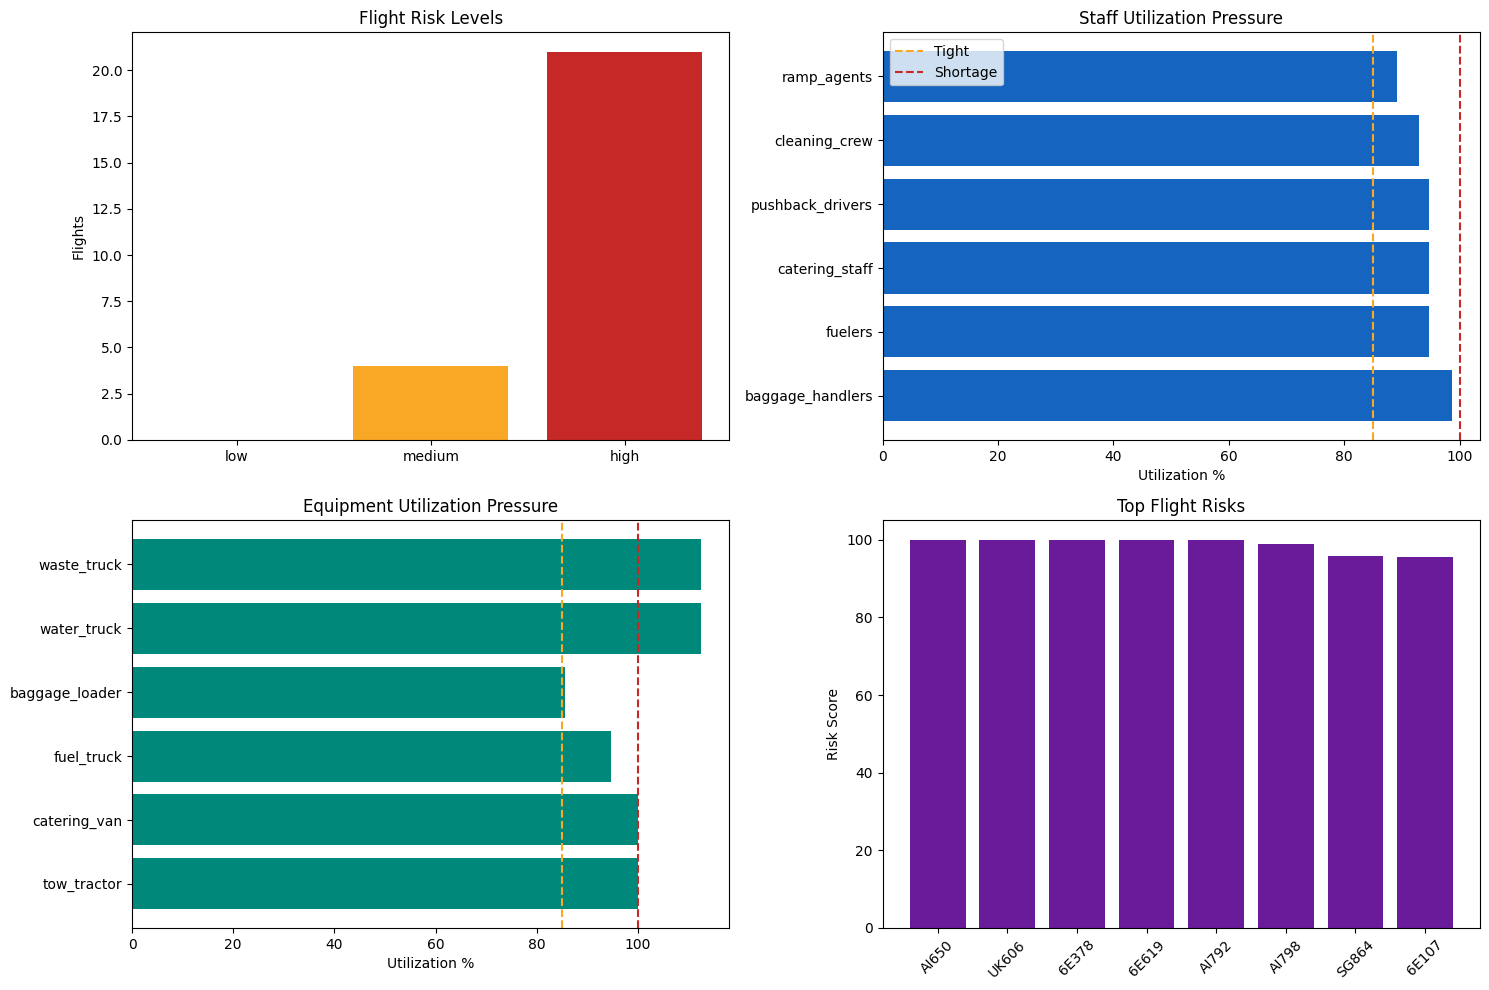

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

risk_counts = risk_df['risk_level'].value_counts().reindex(['low', 'medium', 'high'], fill_value=0)
axes[0, 0].bar(risk_counts.index.astype(str), risk_counts.values, color=['#2e7d32', '#f9a825', '#c62828'])
axes[0, 0].set_title('Flight Risk Levels')
axes[0, 0].set_ylabel('Flights')

axes[0, 1].barh(staff_capacity['resource'], staff_capacity['utilization_pct'], color='#1565c0')
axes[0, 1].axvline(85, color='#f9a825', linestyle='--', label='Tight')
axes[0, 1].axvline(100, color='#c62828', linestyle='--', label='Shortage')
axes[0, 1].set_title('Staff Utilization Pressure')
axes[0, 1].set_xlabel('Utilization %')
axes[0, 1].legend()

axes[1, 0].barh(equipment_capacity['resource'], equipment_capacity['utilization_pct'], color='#00897b')
axes[1, 0].axvline(85, color='#f9a825', linestyle='--')
axes[1, 0].axvline(100, color='#c62828', linestyle='--')
axes[1, 0].set_title('Equipment Utilization Pressure')
axes[1, 0].set_xlabel('Utilization %')

top_risk = risk_df.sort_values('risk_score', ascending=False).head(8)
axes[1, 1].bar(top_risk['flight_id'], top_risk['risk_score'], color='#6a1b9a')
axes[1, 1].set_title('Top Flight Risks')
axes[1, 1].set_ylabel('Risk Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Export Backend-Ready Payload

In [10]:
def build_command_center_payload(kpis, risks, actions, conflicts):
    return {
        'generated_at': now.isoformat(),
        'weather': weather_state,
        'kpis': kpis.iloc[0].to_dict(),
        'top_risks': risks.sort_values('risk_score', ascending=False).head(10)[[
            'flight_id', 'airline', 'aircraft_type', 'gate', 'status', 'arrival_delay_min', 'risk_score', 'risk_level'
        ]].assign(risk_level=lambda df: df['risk_level'].astype(str)).to_dict(orient='records'),
        'actions': actions.head(15).assign(risk_level=lambda df: df['risk_level'].astype(str)).to_dict(orient='records'),
        'conflicts': conflicts.to_dict(orient='records') if not conflicts.empty else [],
    }


payload = build_command_center_payload(kpi_df, risk_df, action_plan_df, conflicts_df)
payload

{'generated_at': '2026-04-27T09:00:00',
 'weather': {'condition': 'rain_expected',
  'visibility_km': 4.5,
  'crosswind_knots': 18,
  'storm_probability_pct': 42},
 'kpis': {'active_flights': 25.0,
  'high_risk_flights': 21.0,
  'medium_risk_flights': 4.0,
  'avg_delay_risk': 83.1,
  'staff_utilization_pct': 94.1,
  'equipment_utilization_pct': 100.9,
  'open_conflicts': 1.0,
  'critical_actions': 15.0,
  'command_center_score': 43.9},
 'top_risks': [{'flight_id': 'AI650',
   'airline': 'IndiGo',
   'aircraft_type': 'A320',
   'gate': 'G17',
   'status': 'turnaround',
   'arrival_delay_min': -12.0,
   'risk_score': 100.0,
   'risk_level': 'high'},
  {'flight_id': 'UK606',
   'airline': 'Vistara',
   'aircraft_type': 'A350',
   'gate': 'G08',
   'status': 'arrived',
   'arrival_delay_min': -12.0,
   'risk_score': 100.0,
   'risk_level': 'high'},
  {'flight_id': '6E378',
   'airline': 'SpiceJet',
   'aircraft_type': 'A320',
   'gate': 'G20',
   'status': 'delayed',
   'arrival_delay_min'

In [11]:
print('COMMAND CENTER SUMMARY')
print('======================')
print(f"Active flights monitored: {payload['kpis']['active_flights']}")
print(f"High-risk flights: {payload['kpis']['high_risk_flights']}")
print(f"Open conflicts: {payload['kpis']['open_conflicts']}")
print(f"Critical actions: {payload['kpis']['critical_actions']}")
print(f"Command Center Score: {payload['kpis']['command_center_score']}")
print('\nTop recommended actions:')
for item in payload['actions'][:5]:
    print(f"- [{item['action_type']}] {item['recommendation']}")

COMMAND CENTER SUMMARY
Active flights monitored: 25.0
High-risk flights: 21.0
Open conflicts: 1.0
Critical actions: 15.0
Command Center Score: 43.9

Top recommended actions:
- [critical_recovery] Open command incident, pre-position all ground teams, and protect departure slot.
- [critical_recovery] Open command incident, pre-position all ground teams, and protect departure slot.
- [critical_recovery] Open command incident, pre-position all ground teams, and protect departure slot.
- [critical_recovery] Open command incident, pre-position all ground teams, and protect departure slot.
- [critical_recovery] Open command incident, pre-position all ground teams, and protect departure slot.
